# Problem Statement 2 :--->

A logistics company recorded the time taken for delivery and the time taken for the sorting of the items for delivery. Build a Simple Linear Regression model to find the relationship between delivery time and sorting time with delivery time as the target variable. Apply necessary transformations and record the RMSE and correlation coefficient values for different models.

# Business objective-->
Understand how sorting time impacts delivery time to improve logistics operations.

If sorting time is a significant predictor of delivery time, optimizing sorting processes can lead to faster deliveries.

Helps the company allocate the right resources (manpower, transportation, etc.) to minimize delays.

# Constraints-->
The model only considers sorting time as a predictor, which may not capture other real-world factors affecting delivery time.

Interpretability over complexity: The company might prefer a simple model for easy implementation and interpretation.

In [1]:
#import reuired models
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
from sklearn.model_selection import train_test_split

In [2]:
# Load the dataset
df = pd.read_csv("delivery_time.csv")

In [3]:
# Check the dataset structure
df.head()

,Delivery Time,Sorting Time
0,21.00,10
1,13.50,4
2,19.75,6
3,24.00,9
4,29.00,10


In [4]:
# Check the dataset structure
df.head()

,Delivery Time,Sorting Time
0,21.00,10
1,13.50,4
2,19.75,6
3,24.00,9
4,29.00,10


In [5]:
# chaeck shape of dataset
df.shape

(21, 2)

In [6]:
# description of dataset
df.describe()

,Delivery Time,Sorting Time
count,21.000000,21.000000
mean,16.790952,6.190476
std,5.074901,2.542028
min,8.000000,2.000000
25%,13.500000,4.000000
50%,17.830000,6.000000
75%,19.750000,8.000000
max,29.000000,10.000000


In [7]:
# Rename columns for ease of use
df.columns = ["Delivery_Time", "Sorting_Time"]

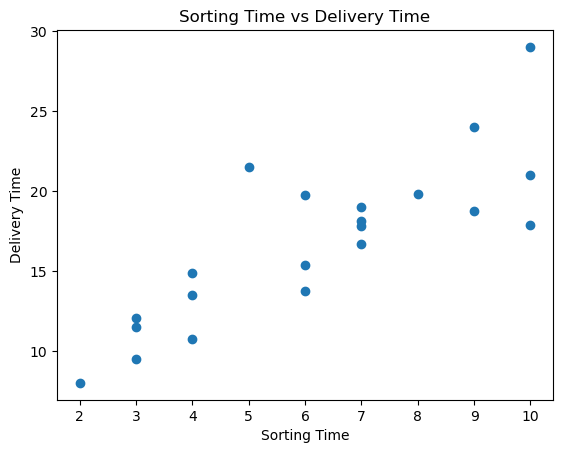

In [8]:
# Scatter plot
plt.scatter(df.Sorting_Time, df.Delivery_Time)
plt.xlabel("Sorting Time")
plt.ylabel("Delivery Time")
plt.title("Sorting Time vs Delivery Time")
plt.show()

In [9]:
# Correlation coefficient
corr_coeff = np.corrcoef(df.Sorting_Time, df.Delivery_Time)[0,1]
print(f"Correlation Coefficient: {corr_coeff}")

Correlation Coefficient: 0.8259972607955325


In [10]:
# Model 1: Simple Linear Regression
model1 = smf.ols('Delivery_Time ~ Sorting_Time', data=df).fit()
print(model1.summary())

                            OLS Regression Results                            
Dep. Variable:          Delivery_Time   R-squared:                       0.682
Model:                            OLS   Adj. R-squared:                  0.666
Method:                 Least Squares   F-statistic:                     40.80
Date:                Mon, 03 Mar 2025   Prob (F-statistic):           3.98e-06
Time:                        13:36:47   Log-Likelihood:                -51.357
No. Observations:                  21   AIC:                             106.7
Df Residuals:                      19   BIC:                             108.8
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept        6.5827      1.722      3.823   

In [11]:
# Predictions
pred1 = model1.predict(df.Sorting_Time)
pred1

0     23.072933
1     13.178814
2     16.476853
3     21.423913
4     23.072933
5     16.476853
6     18.125873
7     11.529794
8     23.072933
9     21.423913
10    19.774893
11    13.178814
12    18.125873
13    11.529794
14    11.529794
15    13.178814
16    16.476853
17    18.125873
18     9.880774
19    18.125873
20    14.827833
dtype: float64

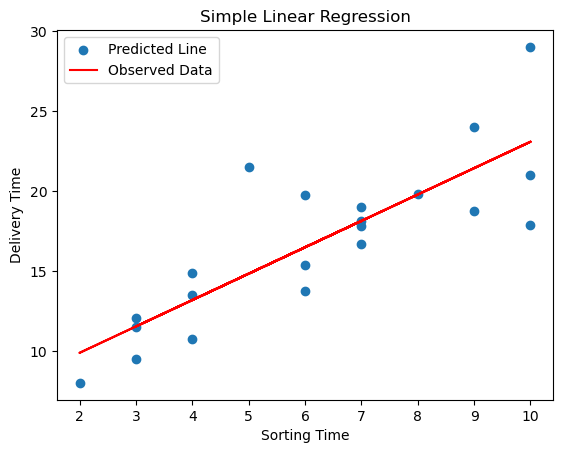

In [12]:
# Regression Line
plt.scatter(df.Sorting_Time, df.Delivery_Time)
plt.plot(df.Sorting_Time, pred1, 'r')
plt.xlabel("Sorting Time")
plt.ylabel("Delivery Time")
plt.title("Simple Linear Regression")
plt.legend(["Predicted Line", "Observed Data"])
plt.show()

In [13]:
# RMSE Calculation
residuals1 = df.Delivery_Time - pred1
rmse1 = np.sqrt(np.mean(residuals1 ** 2))
print(f"RMSE (Simple Model): {rmse1}")

RMSE (Simple Model): 2.7916503270617654


In [14]:
#Model 2: Log Transformation (Log(Y) ~ X)
df['log_Delivery_Time'] = np.log(df.Delivery_Time)

In [15]:
log_model = smf.ols('log_Delivery_Time ~ Sorting_Time', data=df).fit()
print(log_model.summary())

                            OLS Regression Results                            
Dep. Variable:      log_Delivery_Time   R-squared:                       0.711
Model:                            OLS   Adj. R-squared:                  0.696
Method:                 Least Squares   F-statistic:                     46.73
Date:                Mon, 03 Mar 2025   Prob (F-statistic):           1.59e-06
Time:                        13:37:36   Log-Likelihood:                 7.7920
No. Observations:                  21   AIC:                            -11.58
Df Residuals:                      19   BIC:                            -9.495
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept        2.1214      0.103     20.601   

In [16]:
# Predictions using log transformation
log_pred = np.exp(log_model.predict(df.Sorting_Time))

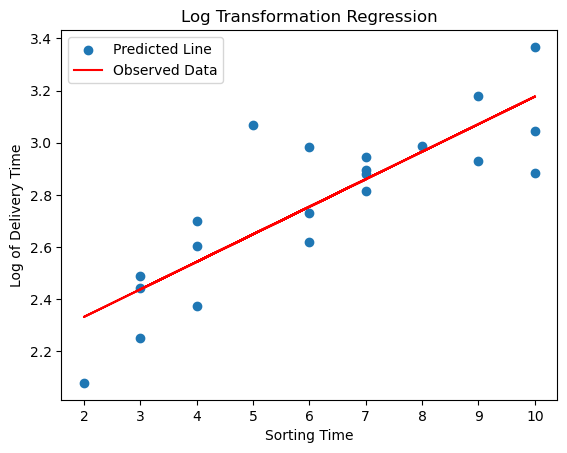

In [17]:
# Regression Line (Log Model)
plt.scatter(df.Sorting_Time, np.log(df.Delivery_Time))
plt.plot(df.Sorting_Time, log_model.predict(df.Sorting_Time), 'r')
plt.xlabel("Sorting Time")
plt.ylabel("Log of Delivery Time")
plt.title("Log Transformation Regression")
plt.legend(["Predicted Line", "Observed Data"])
plt.show()

In [18]:
# RMSE Calculation for Log Model
residuals2 = df.Delivery_Time - log_pred
rmse2 = np.sqrt(np.mean(residuals2 ** 2))
print(f"RMSE (Log Model): {rmse2}")

RMSE (Log Model): 2.940250323056201


In [19]:
#Model 3: Polynomial Regression (Y ~ X + X²)
df['Sorting_Time_Square'] = df.Sorting_Time ** 2

In [20]:
poly_model = smf.ols('Delivery_Time ~ Sorting_Time + Sorting_Time_Square', data=df).fit()
print(poly_model.summary())

                            OLS Regression Results                            
Dep. Variable:          Delivery_Time   R-squared:                       0.693
Model:                            OLS   Adj. R-squared:                  0.659
Method:                 Least Squares   F-statistic:                     20.36
Date:                Mon, 03 Mar 2025   Prob (F-statistic):           2.39e-05
Time:                        13:38:21   Log-Likelihood:                -50.981
No. Observations:                  21   AIC:                             108.0
Df Residuals:                      18   BIC:                             111.1
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept               3.5222    

In [21]:
# Predictions using Polynomial Model
pred3 = poly_model.predict(df[['Sorting_Time', 'Sorting_Time_Square']])

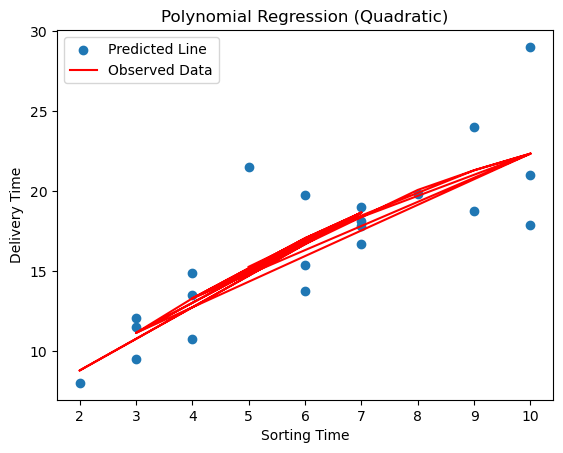

In [22]:
# Regression Line (Polynomial Model)
plt.scatter(df.Sorting_Time, df.Delivery_Time)
plt.plot(df.Sorting_Time, pred3, 'r')
plt.xlabel("Sorting Time")
plt.ylabel("Delivery Time")
plt.title("Polynomial Regression (Quadratic)")
plt.legend(["Predicted Line", "Observed Data"])
plt.show()

In [23]:
# RMSE Calculation for Polynomial Model
residuals3 = df.Delivery_Time - pred3
rmse3 = np.sqrt(np.mean(residuals3 ** 2))
print(f"RMSE (Polynomial Model): {rmse3}")

RMSE (Polynomial Model): 2.7421482037801215


In [24]:
#Compare RMSE Values for All Models
print("--- RMSE Comparison ---")
print(f"Simple Linear Regression RMSE: {rmse1}")
print(f"Log Transformation RMSE: {rmse2}")
print(f"Polynomial Regression RMSE: {rmse3}")

--- RMSE Comparison ---
Simple Linear Regression RMSE: 2.7916503270617654
Log Transformation RMSE: 2.940250323056201
Polynomial Regression RMSE: 2.7421482037801215


In [25]:
#Compare Correlation Coefficients
corr_log = np.corrcoef(df.Sorting_Time, np.log(df.Delivery_Time))[0, 1]
corr_poly = np.corrcoef(df.Sorting_Time, pred3)[0, 1]

print("--- Correlation Coefficient Comparison ---")
print(f"Simple Linear Regression: {corr_coeff}")
print(f"Log Transformation: {corr_log}")
print(f"Polynomial Regression: {corr_poly}")

--- Correlation Coefficient Comparison ---
Simple Linear Regression: 0.8259972607955325
Log Transformation: 0.8431772637224149
Polynomial Regression: 0.991914591428056


Observations from Regression Models Analysis

1. Model Performance (Based on RMSE)

Polynomial Regression (RMSE = 2.7421) performs the best since it has the lowest RMSE, indicating the best predictive accuracy.
Simple Linear Regression (RMSE = 2.7916) is slightly worse but still performs well.
Log Transformation (RMSE = 2.9402) has the highest RMSE, suggesting it is the least effective model.

2. Correlation Coefficient Analysis

Polynomial Regression (0.9919) shows the strongest correlation between Sorting Time and Delivery Time, suggesting a strong non-linear relationship.
Log Transformation (0.8431) has a higher correlation than Simple Linear Regression, meaning log transformation somewhat improves the relationship.
Simple Linear Regression (0.8260) has the lowest correlation coefficient, meaning it captures the relationship less effectively.

3. Comparison of Model Fit

The Polynomial Regression model (quadratic model) best fits the data, meaning the relationship between Sorting Time and Delivery Time is likely non-linear.
Simple Linear Regression is still a reasonable choice but does not capture non-linearity.
Log Transformation does not improve the fit significantly, as seen from its higher RMSE.

Since Polynomial Regression has the lowest RMSE (2.7421) and highest correlation (0.9919), it is the best model for predicting Delivery Time based on Sorting Time.